In [2]:
#importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
data=pd.read_csv("agriculture_dataset.csv")
data.head()

,Farm_ID,Crop_Type,Farm_Area(acres),Irrigation_Type,Fertilizer_Used(tons),Pesticide_Used(kg),Yield(tons),Soil_Type,Season,Water_Usage(cubic meters)
0,F001,Cotton,329.40,Sprinkler,8.14,2.21,14.44,Loamy,Kharif,76648.20
1,F002,Carrot,18.67,Manual,4.77,4.36,42.91,Peaty,Kharif,68725.54
2,F003,Sugarcane,306.03,Flood,2.91,0.56,33.44,Silty,Kharif,75538.56
3,F004,Tomato,380.21,Rain-fed,3.32,4.35,34.08,Silty,Zaid,45401.23
4,F005,Tomato,135.56,Sprinkler,8.33,4.48,43.28,Clay,Zaid,93718.69


In [4]:
data.shape

(50, 10)

In [5]:
data.columns

Index(['Farm_ID', 'Crop_Type', 'Farm_Area(acres)', 'Irrigation_Type',
       'Fertilizer_Used(tons)', 'Pesticide_Used(kg)', 'Yield(tons)',
       'Soil_Type', 'Season', 'Water_Usage(cubic meters)'],
      dtype='object')

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Farm_ID                    50 non-null     object 
 1   Crop_Type                  50 non-null     object 
 2   Farm_Area(acres)           50 non-null     float64
 3   Irrigation_Type            50 non-null     object 
 4   Fertilizer_Used(tons)      50 non-null     float64
 5   Pesticide_Used(kg)         50 non-null     float64
 6   Yield(tons)                50 non-null     float64
 7   Soil_Type                  50 non-null     object 
 8   Season                     50 non-null     object 
 9   Water_Usage(cubic meters)  50 non-null     float64
dtypes: float64(5), object(5)
memory usage: 4.0+ KB


In [7]:
data.describe()

,Farm_Area(acres),Fertilizer_Used(tons),Pesticide_Used(kg),Yield(tons),Water_Usage(cubic meters)
count,50.000000,50.000000,50.000000,50.000000,50.000000
mean,254.963800,4.905400,2.398000,27.059200,56724.295600
std,139.417782,2.732689,1.438613,13.345789,27264.992053
min,12.500000,0.500000,0.140000,3.860000,5869.750000
25%,135.710000,2.437500,0.972500,16.190000,37818.152500
50%,281.980000,5.045000,2.330000,28.970000,54097.075000
75%,368.107500,6.885000,3.417500,37.860000,82240.032500
max,483.880000,9.960000,4.990000,48.020000,94754.730000


In [8]:
#checking null values
data.isnull().sum()

Farm_ID                      0
Crop_Type                    0
Farm_Area(acres)             0
Irrigation_Type              0
Fertilizer_Used(tons)        0
Pesticide_Used(kg)           0
Yield(tons)                  0
Soil_Type                    0
Season                       0
Water_Usage(cubic meters)    0
dtype: int64

In [9]:
#checking duplicates
data.duplicated().sum()

np.int64(0)

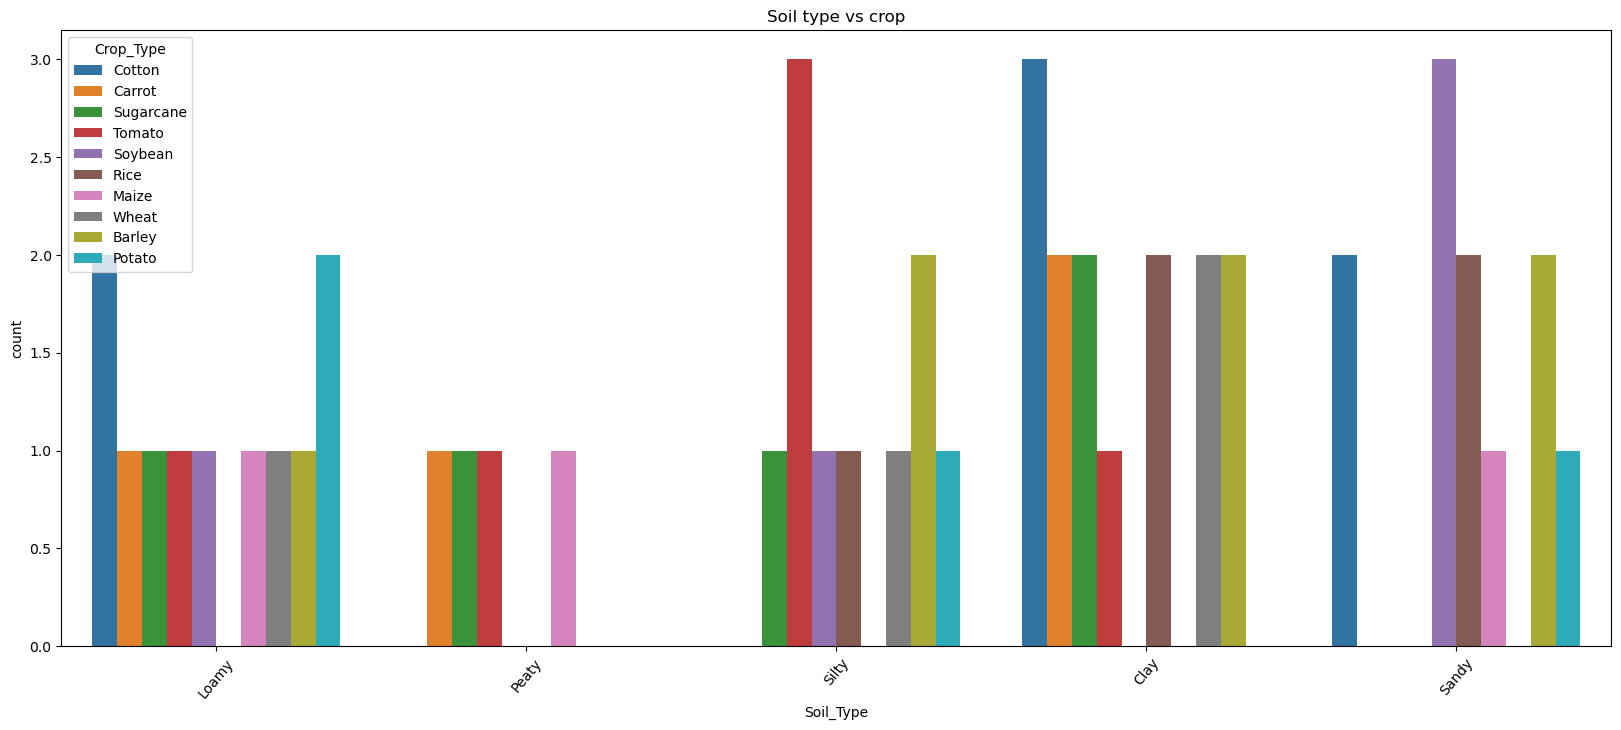

In [10]:
#soil type vs Crop
plt.figure(figsize=[20,8])
sns.countplot(x="Soil_Type",hue="Crop_Type",data=data)
plt.title("Soil type vs crop")
plt.xticks(rotation=50)
plt.show()

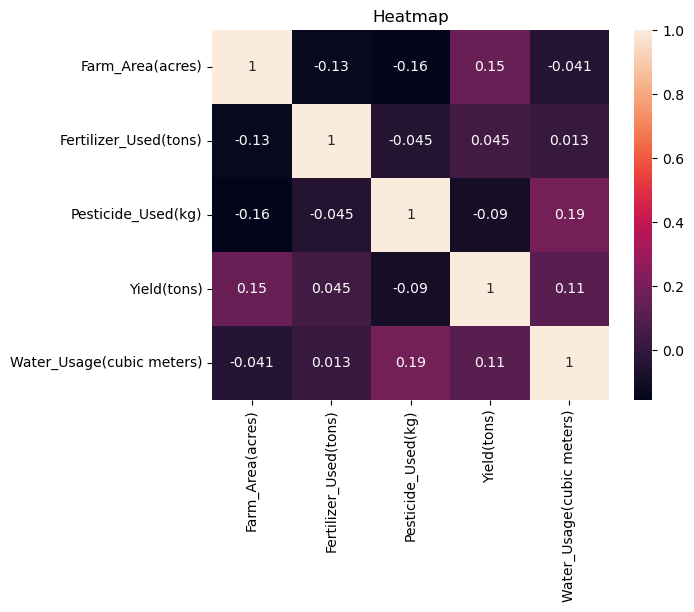

In [11]:
#correlation heatmap
plt.Figure(figsize=[20,8])
sns.heatmap(data.corr(numeric_only=True),annot=True)
plt.title("Heatmap")
plt.show()

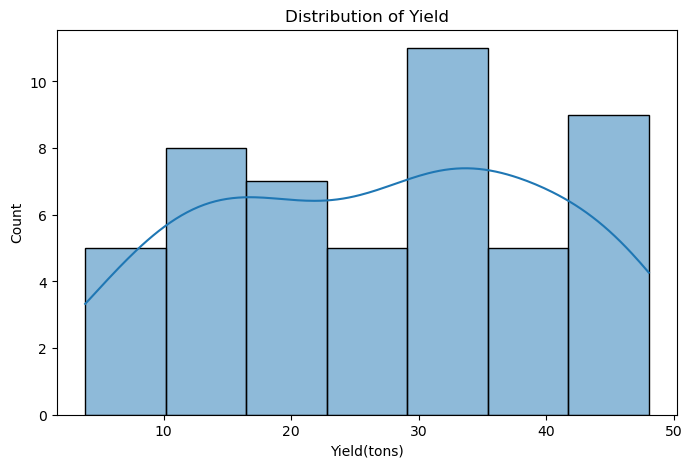

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(data['Yield(tons)'], kde=True)
plt.title("Distribution of Yield")
plt.show()


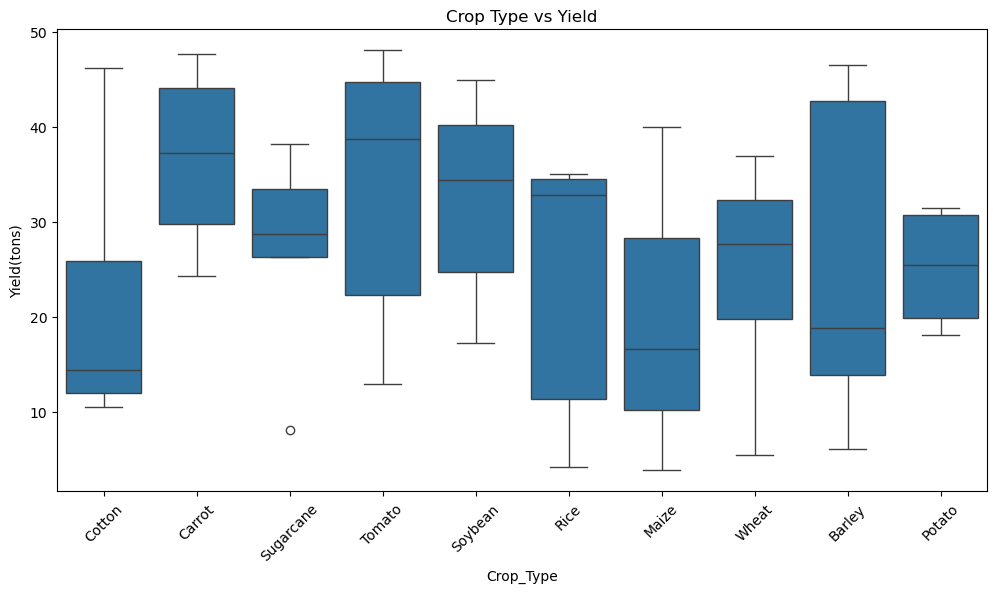

In [13]:
plt.figure(figsize=(12,6))
sns.boxplot(x="Crop_Type", y="Yield(tons)", data=data)
plt.xticks(rotation=45)
plt.title("Crop Type vs Yield")
plt.show()


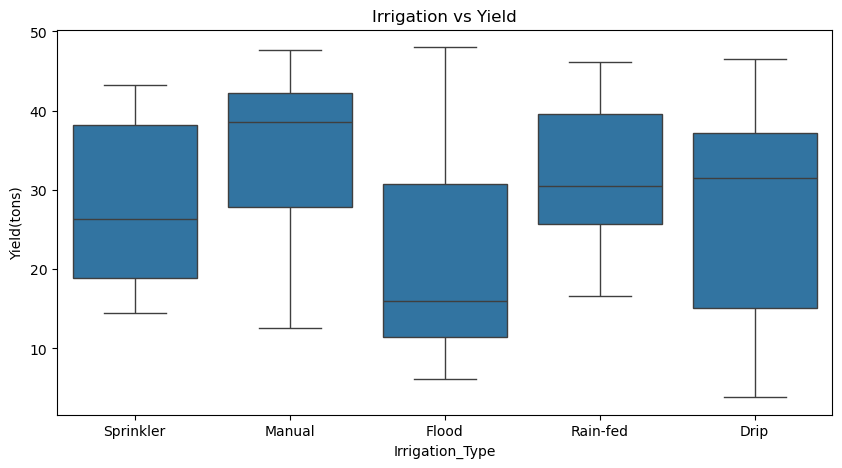

In [16]:
plt.figure(figsize=(10,5))
sns.boxplot(x="Irrigation_Type", y="Yield(tons)", data=data)
plt.title("Irrigation vs Yield")
plt.show()


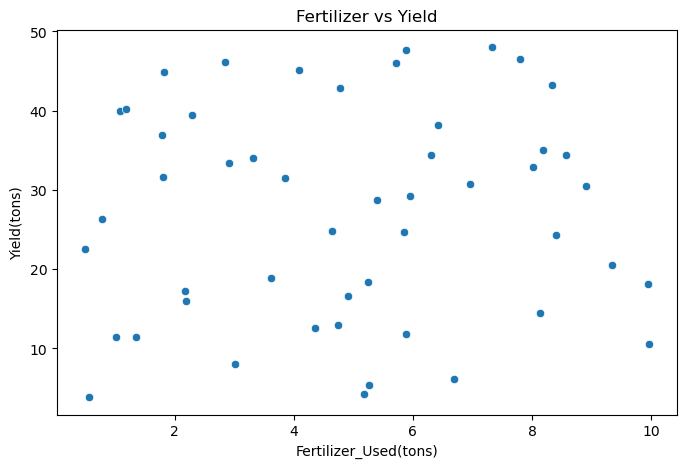

In [17]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="Fertilizer_Used(tons)", y="Yield(tons)", data=data)
plt.title("Fertilizer vs Yield")
plt.show()


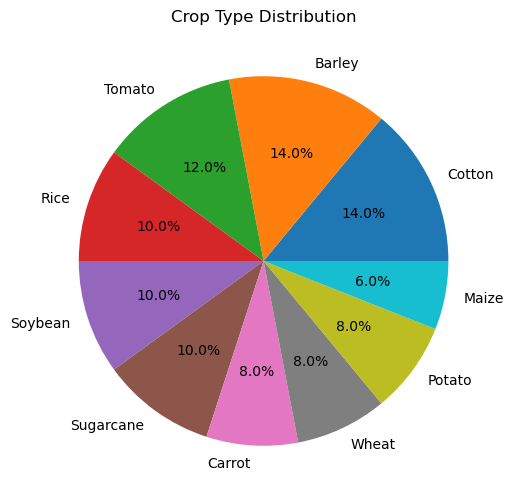

In [22]:
plt.figure(figsize=(6,6))
data['Crop_Type'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Crop Type Distribution")
plt.ylabel("")
plt.show()


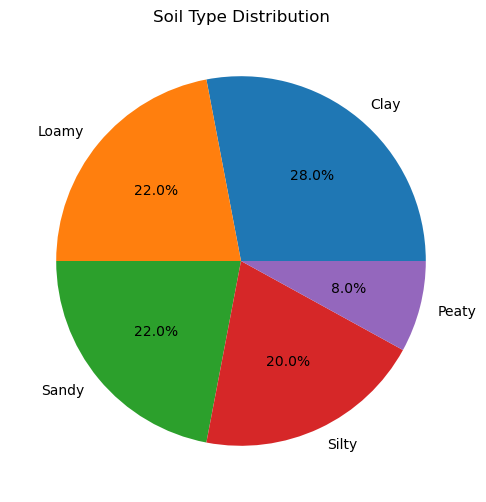

In [18]:
plt.figure(figsize=(6,6))
data['Soil_Type'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Soil Type Distribution")
plt.ylabel("")
plt.show()


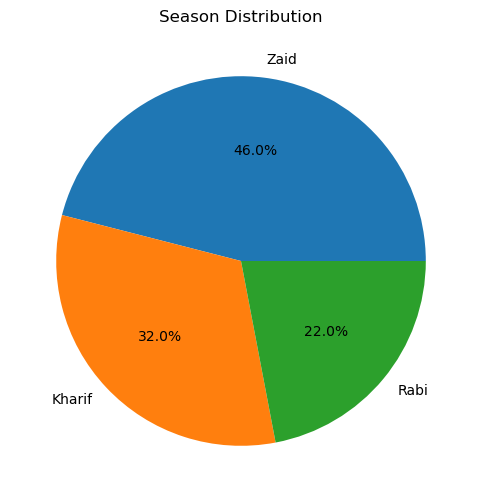

In [19]:
plt.figure(figsize=(6,6))
data['Season'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Season Distribution")
plt.ylabel("")
plt.show()


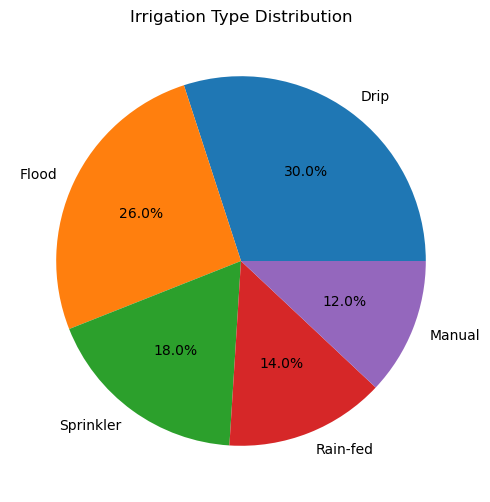

In [20]:
plt.figure(figsize=(6,6))
data['Irrigation_Type'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Irrigation Type Distribution")
plt.ylabel("")
plt.show()


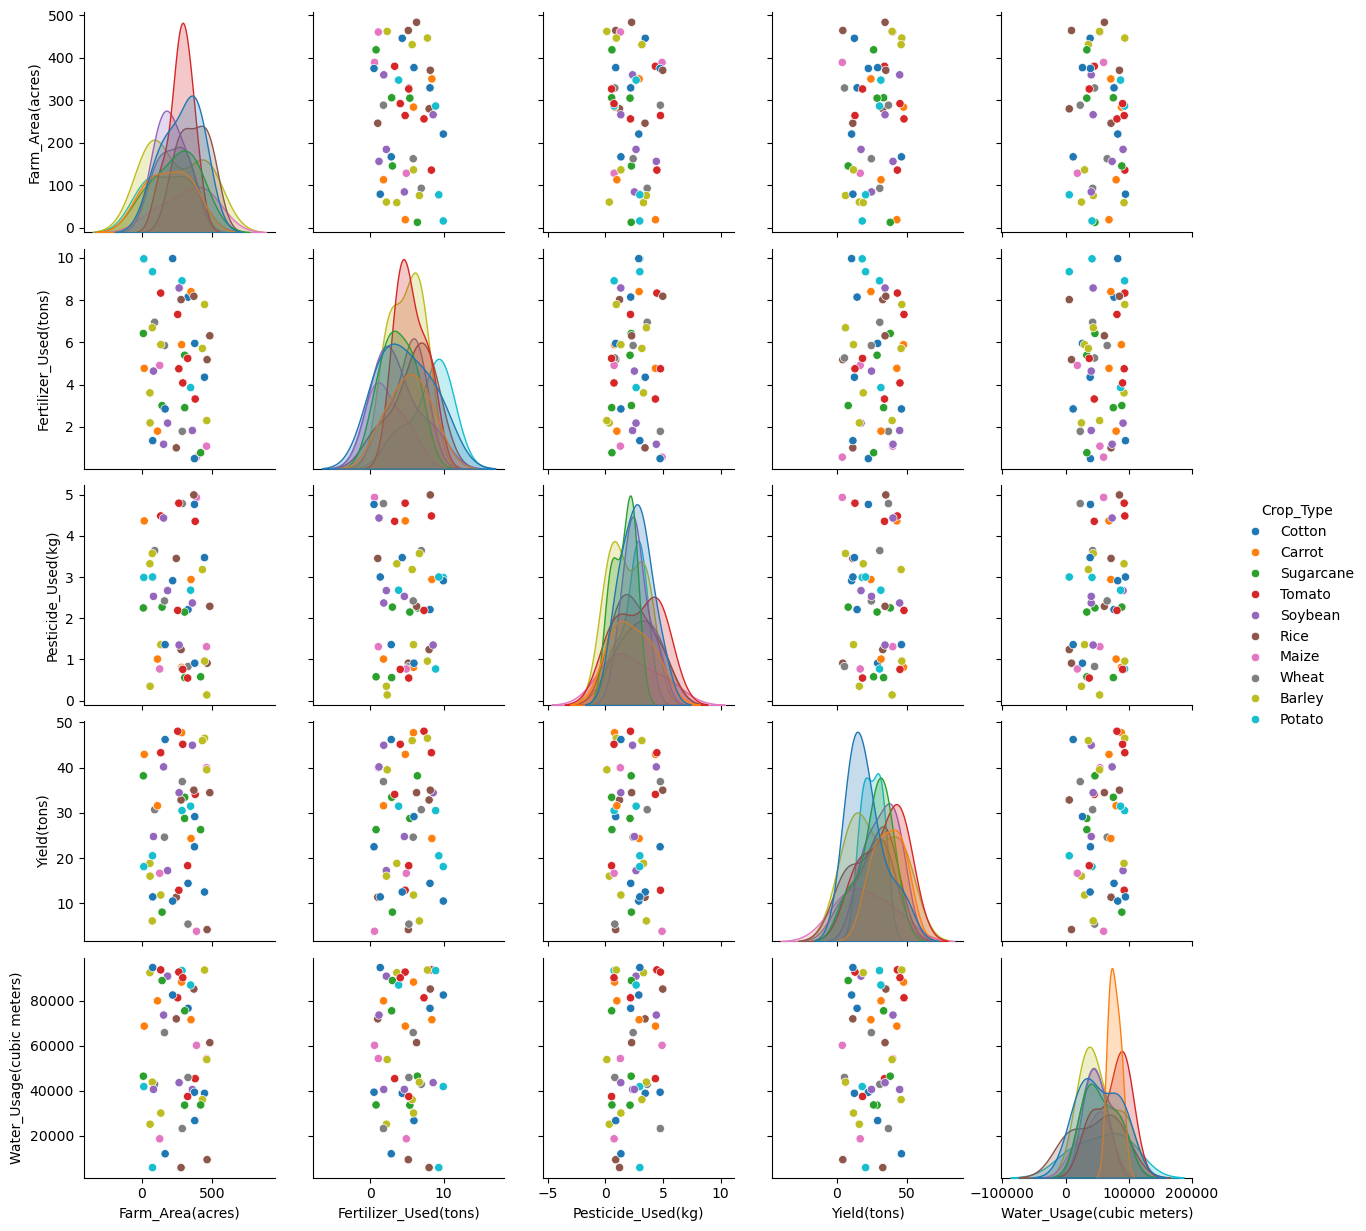

In [14]:
sns.pairplot(data, hue="Crop_Type")
plt.show()


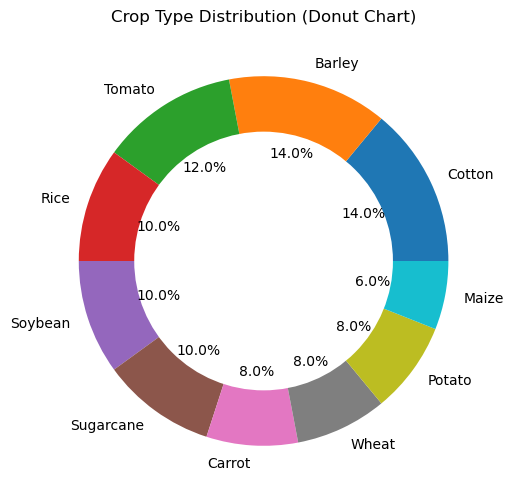

In [23]:
plt.figure(figsize=(6,6))
counts = data['Crop_Type'].value_counts()

plt.pie(counts, labels=counts.index, autopct='%1.1f%%')
centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Crop Type Distribution (Donut Chart)")
plt.show()


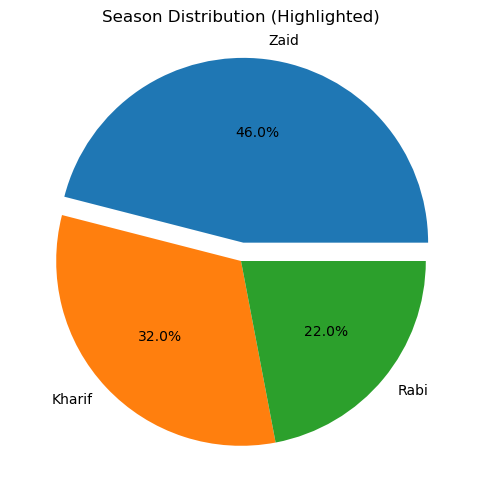

In [25]:
counts = data['Season'].value_counts()
explode = [0.1 if i==counts.max() else 0 for i in counts]

plt.figure(figsize=(6,6))
plt.pie(counts, labels=counts.index,
        autopct='%1.1f%%', explode=explode)
plt.title("Season Distribution (Highlighted)")
plt.show()
